# Notebook 3 (v2) - VelOT cell-number scaling

**Goal.** Characterise the empirical complexity of the full VelOT pipeline as a function
of `n_cells` on the easy bifurcation, comparing **GPU** and **CPU (8 threads)** regimes.
Cell counts are obtained by rebuilding the synthetic dataset at density-scale ×0.5, ×1,
×2, ×4 and ×8.

Each `(condition × scale × seed)` is a separate subprocess so that hardware settings
(`CUDA_VISIBLE_DEVICES`, `OMP_NUM_THREADS`, …) can be enforced cleanly.

**Outputs:**
- Master scaling figure (6 panels: total runtime + fits, stage scaling, memory, ms/cell,
  window-pair growth, quality stability).
- Stage-level small multiples (one panel per stage, both conditions overlaid).
- Empirical exponent table with R² and 95 % CIs.

In [1]:
from pathlib import Path
import os, sys, warnings, importlib.util, json, time, subprocess, warnings

warnings.filterwarnings("ignore")

REQUIRED_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "anndata": "anndata",
    "scanpy": "scanpy",
    "ot": "POT",
    "torch": "torch",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_IMPORTS.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ImportError(
        "Missing packages:\n"
        + "\n".join(missing)
        + "\n\nInstall them manually with:\n"
        + f"pip install {' '.join(missing)}"
    )

# Import torch BEFORE velot
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Locate VelOT root
PROJECT_ROOT = Path.cwd().resolve()

CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    PROJECT_ROOT.parent.parent,
]

VELOT_IMPORT_ROOT = None

for c in CANDIDATES:
    if (c / "velot").is_dir():
        VELOT_IMPORT_ROOT = c
        sys.path.insert(0, str(c))
        break

import velot

print(f"VelOT : {getattr(velot, '__version__', 'unknown')}")
print(f"Torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
print(f"CWD   : {PROJECT_ROOT}")
print(f"VelOT import root: {VELOT_IMPORT_ROOT}")

VelOT : 0.1.0
Torch : 2.7.1+cu118
CUDA  : True
CWD   : /home/user/Documents/velot/notebooks/supplementary
VelOT import root: /home/user/Documents/velot


In [13]:
# Publication style — Nature/NMETH defaults with a Wong colourblind-safe palette.
RUN_ROOT = PROJECT_ROOT / "results_velot_publication_v2"
FIGDIR   = RUN_ROOT / "figures"
TABLEDIR = RUN_ROOT / "tables"
JSONDIR  = RUN_ROOT / "json"
for d in (FIGDIR, TABLEDIR, JSONDIR): d.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.transparent": False,
    # "font.family": "serif",
    # "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman"],
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 12, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.frameon": False, "legend.handlelength": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "lines.linewidth": 1.2, "lines.markersize": 5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.prop_cycle": plt.cycler("color",
        ["#0072B2","#D55E00","#009E73","#CC79A7","#F0E442","#56B4E9","#E69F00","#332288"]),
})

# Wong palette (colourblind-safe, used as named colours throughout)
WONG = {
    "blue":   "#0072B2", "orange": "#D55E00", "green":  "#009E73",
    "magenta":"#CC79A7", "yellow": "#F0E442", "skyblue":"#56B4E9",
    "amber":  "#E69F00", "purple": "#332288", "grey":   "#999999",
    "black":  "#000000", "red":    "#882255", "teal":   "#117733",
}

# Semantic colour roles
ROLE = {
    "gpu":      WONG["blue"],
    "cpu1":     WONG["orange"],
    "cpu8":     WONG["amber"],
    "baseline": WONG["green"],
    "ablation": WONG["purple"],
    "primary":  WONG["blue"],
    "secondary":WONG["magenta"],
    "accent":   WONG["green"],
    "neutral":  WONG["grey"],
    "Root":     WONG["grey"],
    "Branch_1": WONG["blue"],
    "Branch_2": WONG["orange"],
}

def panel_label(ax, letter, x=-0.18, y=1.05, fontsize=12, **kw):
    """Add a bold sans-serif (a)/(b)/(c) panel label in figure-corner style."""
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold", va="bottom", ha="left",
            family="sans-serif", **kw)

def savefig(fig, stem, folder=None, close=False):
    """Save both PDF (vector, editable in Illustrator) and PNG (300 dpi)."""
    folder = Path(folder) if folder else FIGDIR
    folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(folder / f"{stem}.png", bbox_inches="tight")
    print(f"saved: {folder / stem}.{{pdf,png}}")
    if close: plt.close(fig)

def add_significance_bracket(ax, x1, x2, y, text, color="black",
                              line_kw=None, text_kw=None):
    """Draw a horizontal significance bracket between x1 and x2 at y, with text above."""
    line_kw = {"lw": 0.9, "color": color, **(line_kw or {})}
    text_kw = {"ha": "center", "va": "bottom", "fontsize": 8,
               "color": color, **(text_kw or {})}
    dy = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], **line_kw)
    ax.text((x1 + x2) / 2, y + dy * 1.1, text, **text_kw)

def stars(p):
    """ASA-style significance stars."""
    if   p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else:          return "ns"


In [3]:
# Easy synthetic bifurcation — identical parameterisation to the working notebooks
# so that figures and timing here are directly comparable to those reports.
BASE_DENSITIES = {
    "root_density":     400,
    "root_position":    3.0,
    "branch_densities": (300, 400),
    "branch_positions": (5.0, 10.0),
    "branch_slopes":    (1.0, -1.0),
    "noise_level":      0.2,
    "extra_dimensions": 1,
    "n_neighbors":      50,
}
EDGES = [("Root", "Branch_1"), ("Root", "Branch_2")]
TERMINALS = ["Root", "Branch_1", "Branch_2"]

def build_easy_bifurcation(seed=42, density_scale=1.0,
                           noise_level=None, imbalance=None, n_neighbors=None):
    """Build the easy synthetic bifurcation used throughout these notebooks."""
    p = dict(BASE_DENSITIES)
    if noise_level is not None: p["noise_level"] = float(noise_level)
    if n_neighbors is not None: p["n_neighbors"] = int(n_neighbors)
    root = max(20, int(round(p["root_density"] * density_scale)))
    b1, b2 = p["branch_densities"]
    b1 = max(20, int(round(b1 * density_scale)))
    b2 = max(20, int(round(b2 * density_scale)))
    if imbalance is not None:
        b1 = max(20, int(round(b1 * float(imbalance))))
    adata = velot.datasets.synthetic_bifurcation(
        root_density=root, root_position=p["root_position"],
        branch_densities=(b1, b2), branch_positions=p["branch_positions"],
        branch_slopes=p["branch_slopes"], noise_level=p["noise_level"],
        extra_dimensions=p["extra_dimensions"], n_neighbors=p["n_neighbors"],
        seed=seed,
    )
    velot.pp.pseudotime(adata, key="true_pseudotime")
    adata.obs["clusters_id"]  = adata.obs["celltype"].cat.codes.astype(int)
    adata.obs["celltype_str"] = adata.obs["celltype"].astype(str)
    return adata


In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

def scalar_metrics_from_results(results):
    out = {k: float(results.get(k, np.nan))
           for k in ("iccoh_mean", "iccoh_median", "cbdir_mean", "cbdir_median")}
    out["quality_mean"] = float(np.nanmean([out["iccoh_mean"], out["cbdir_mean"]]))
    return out

def confidence_summary(adata):
    conf = np.asarray(adata.obs.get("velot_confidence",
                                    np.full(adata.n_obs, np.nan)), dtype=float)
    return {"confidence_mean":   float(np.nanmean(conf)),
            "confidence_median": float(np.nanmedian(conf)),
            "confidence_zero_frac": float(np.mean(conf <= 0))}

def future_alignment_score(adata, basis_key="X_pca",
                           velocity_key="velot_velocity_pca",
                           k=25, min_dt=0.01):
    """Local alignment of velocity to pseudotime-future neighbours."""
    X = np.asarray(adata.obsm[basis_key])
    V = np.asarray(adata.obsm[velocity_key])
    pt = np.asarray(adata.obs["true_pseudotime"].values, dtype=float)
    nn_ = NearestNeighbors(n_neighbors=min(max(k * 4, k + 1), adata.n_obs)).fit(X)
    _, idx = nn_.kneighbors(X)
    scores = []
    for i in range(adata.n_obs):
        cand = idx[i]; cand = cand[pt[cand] > pt[i] + min_dt]
        cand = cand[cand != i]
        if len(cand) == 0: continue
        cand = cand[:k]
        target = X[cand].mean(axis=0) - X[i]
        d = np.linalg.norm(target) * np.linalg.norm(V[i])
        if d > 1e-12:
            scores.append(float(np.dot(target, V[i]) / d))
    return float(np.nanmean(scores)) if scores else np.nan

def run_velot_once(name="baseline", seed=42, density_scale=1.0,
                   noise_level=None, imbalance=None,
                   basis="X_pca", spatial_key="clusters_id", n_clusters=None,
                   window_size=100, overlap_fraction=0.0, min_window_size=20,
                   reg=0.05, lambda_time=1.0, lambda_knn=1.0,
                   smooth=True, n_epochs=300, hidden_dim=128,
                   lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
                   k_smooth=15, use_pseudotime=True, project_umap=True, verbose=False):
    """Run VelOT stage-by-stage; return (adata, record_dict, raw_metrics)."""
    adata = build_easy_bifurcation(seed=seed, density_scale=density_scale,
                                   noise_level=noise_level, imbalance=imbalance)
    times = {}
    def tic(stage):
        s = time.perf_counter()
        return lambda: times.__setitem__(stage, time.perf_counter() - s)

    stop = tic("build_windows")
    velot.tl.build_windows(adata, basis=basis, n_clusters=n_clusters,
                           window_size=window_size, overlap_fraction=overlap_fraction,
                           min_window_size=min_window_size, spatial_key=spatial_key,
                           random_state=seed); stop()

    stop = tic("ot")
    velot.tl.compute_ot_velocity(adata, basis=basis, reg=reg,
                                 lambda_time=lambda_time, lambda_knn=lambda_knn); stop()

    raw_key = "velot_velocity_raw_pca" if basis == "X_pca" else "velot_velocity_raw_umap"
    velocity_key_pca = raw_key

    if smooth:
        stop = tic("smooth")
        velot.tl.smooth_velocity(adata, basis=basis.split("X_")[1],
                                 velocity_key=raw_key, n_epochs=n_epochs,
                                 hidden_dim=hidden_dim, lambda_smooth=lambda_smooth,
                                 lambda_curl=lambda_curl, lambda_divergence=lambda_divergence,
                                 k_smooth=k_smooth, use_pseudotime=use_pseudotime,
                                 random_state=seed, verbose=verbose); stop()
        velocity_key_pca = "velot_velocity_pca" if basis == "X_pca" else "velot_velocity_umap"
    else:
        times["smooth"] = 0.0

    if project_umap and basis == "X_pca":
        stop = tic("project_umap")
        if smooth:
            velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap")
            velocity_key_umap = "velot_velocity_umap"
        else:
            velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", "velot_velocity_raw_umap")
            velocity_key_umap = "velot_velocity_raw_umap"
        stop()
    elif basis == "X_umap":
        velocity_key_umap = velocity_key_pca; times["project_umap"] = 0.0
    else:
        velocity_key_umap = None;             times["project_umap"] = np.nan

    stop = tic("metrics")
    results = velot.metrics.summary(adata, cluster_edges=EDGES,
                                    cluster_key="celltype",
                                    embedding_key="X_umap",
                                    velocity_key=velocity_key_umap); stop()

    rec = dict(name=name, seed=seed, n_cells=int(adata.n_obs),
               basis=basis, spatial_key=str(spatial_key),
               n_clusters=n_clusters if n_clusters is not None else np.nan,
               window_size=int(window_size), overlap_fraction=float(overlap_fraction),
               reg=float(reg), lambda_time=float(lambda_time),
               lambda_knn=float(lambda_knn), smooth=bool(smooth),
               n_epochs=int(n_epochs), hidden_dim=int(hidden_dim),
               lambda_smooth=float(lambda_smooth), lambda_curl=float(lambda_curl),
               lambda_divergence=float(lambda_divergence),
               k_smooth=int(k_smooth), use_pseudotime=bool(use_pseudotime),
               n_window_pairs=int(adata.uns.get("velot_windows", {}).get("n_pairs", 0)),
               device=str(adata.uns.get("velot_smoothing", {}).get("device", "raw/no_smoothing")))
    rec.update({f"time_{k}": float(v) for k, v in times.items()})
    rec["time_total"] = float(np.nansum(list(times.values())))
    rec.update(scalar_metrics_from_results(results))
    rec.update(confidence_summary(adata))
    try:
        rec["future_alignment"] = future_alignment_score(
            adata, "X_pca",
            "velot_velocity_pca" if smooth else "velot_velocity_raw_pca")
    except Exception as e:
        rec["future_alignment"] = np.nan
        rec["future_alignment_error"] = str(e)
    return adata, rec, results


In [5]:
def colour_for_celltype(labels):
    """Return per-cell colours using the semantic ROLE palette."""
    return np.array([ROLE.get(str(c), WONG["grey"]) for c in labels])

def scatter_embedding(ax, adata, basis="X_umap", color_key="celltype", s=8, alpha=0.85):
    X = np.asarray(adata.obsm[basis])
    labs = adata.obs[color_key].astype(str).values
    cols = colour_for_celltype(labs)
    ax.scatter(X[:, 0], X[:, 1], c=cols, s=s, lw=0, alpha=alpha, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
    return ax

def quiver_panel(ax, adata, velocity_key="velot_velocity_umap",
                 basis="X_umap", color_key="celltype",
                 every=None, scale_mult=35.0,
                 width=0.0035, alpha=0.75, color="black", s=8):
    """Publication-grade velocity quiver panel."""
    X = np.asarray(adata.obsm[basis])
    V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.7)
    if every is None: every = max(1, adata.n_obs // 220)
    idx = np.arange(0, adata.n_obs, every)
    med = np.nanmedian(np.linalg.norm(V[idx], axis=1))
    scale = max(med * scale_mult, 1e-9)
    ax.quiver(X[idx, 0], X[idx, 1], V[idx, 0], V[idx, 1],
              angles="xy", scale_units="xy", scale=scale,
              width=width, alpha=alpha, color=color,
              edgecolor="white", linewidth=0.3)
    return ax

def streamline_panel(ax, adata, velocity_key="velot_velocity_umap",
                     basis="X_umap", color_key="celltype",
                     density=1.4, ngrid=40, lw=0.7, arrowsize=0.9, s=7):
    """Smoothed streamlines on a regular grid — nicer than quiver for trajectories."""
    from scipy.interpolate import griddata
    X = np.asarray(adata.obsm[basis]); V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.55)
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    pad_x = (xmax - xmin) * 0.05; pad_y = (ymax - ymin) * 0.05
    gx = np.linspace(xmin - pad_x, xmax + pad_x, ngrid)
    gy = np.linspace(ymin - pad_y, ymax + pad_y, ngrid)
    GX, GY = np.meshgrid(gx, gy)
    U = griddata(X, V[:, 0], (GX, GY), method="linear")
    W_ = griddata(X, V[:, 1], (GX, GY), method="linear")
    speed = np.sqrt(U**2 + W_**2)
    if np.all(np.isnan(U)):
        return ax
    ax.streamplot(GX, GY, U, W_, density=density, linewidth=lw, arrowsize=arrowsize,
                  color="black", arrowstyle="->",
                  minlength=0.05)
    return ax

def celltype_legend(ax, loc="lower right", fontsize=7):
    handles = []
    for cat in TERMINALS:
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=ROLE.get(cat, WONG["grey"]),
                                  markersize=7, label=cat))
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False)


## 1. Subprocess scaling driver

In [6]:

SCALING_DIR = RUN_ROOT / "scaling_subprocess"; SCALING_DIR.mkdir(parents=True, exist_ok=True)

scaling_runner_code = r"""
import argparse, json, os, sys, time
ap = argparse.ArgumentParser()
ap.add_argument("--out", required=True)
ap.add_argument("--condition", required=True)
ap.add_argument("--threads", type=int, default=8)
ap.add_argument("--seed", type=int, default=42)
ap.add_argument("--scale", type=float, required=True)
ap.add_argument("--n-epochs", type=int, default=300)
ap.add_argument("--window-size", type=int, default=100)
ap.add_argument("--overlap", type=float, default=0.0)
ap.add_argument("--project-root", required=True)
args = ap.parse_args()
for k in ("OMP_NUM_THREADS","MKL_NUM_THREADS","OPENBLAS_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(k, str(args.threads))
sys.path.insert(0, args.project_root)
import numpy as np, torch, torch.nn as nn
torch.set_num_threads(args.threads)
try: torch.set_num_interop_threads(max(1, min(args.threads, 4)))
except RuntimeError: pass
import velot
EDGES = [("Root","Branch_1"), ("Root","Branch_2")]

def scaled_int(x): return max(20, int(round(x * args.scale)))
def build(seed=42):
    a = velot.datasets.synthetic_bifurcation(
        root_density=scaled_int(400), root_position=3.0,
        branch_densities=(scaled_int(300), scaled_int(400)),
        branch_positions=(5.0, 10.0), branch_slopes=(1.0, -1.0),
        noise_level=0.2, extra_dimensions=1, n_neighbors=50, seed=seed)
    velot.pp.pseudotime(a, key="true_pseudotime")
    a.obs["clusters_id"] = a.obs["celltype"].cat.codes.astype(int)
    return a
def sync():
    if torch.cuda.is_available(): torch.cuda.synchronize()
def time_stage(times, name, fn):
    sync(); t0 = time.perf_counter(); out = fn(); sync()
    times[name] = time.perf_counter() - t0; return out
def scalar_metrics(r):
    out = {k: float(r.get(k, float("nan")))
           for k in ("iccoh_mean","iccoh_median","cbdir_mean","cbdir_median")}
    out["quality_mean"] = float(np.nanmean([out["iccoh_mean"], out["cbdir_mean"]]))
    return out

if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
times = {}; t0_total = time.perf_counter()
a = build(args.seed)
time_stage(times, "build_windows", lambda: velot.tl.build_windows(
    a, basis="X_pca", spatial_key="clusters_id",
    window_size=args.window_size, overlap_fraction=args.overlap,
    min_window_size=20, random_state=args.seed))
time_stage(times, "ot", lambda: velot.tl.compute_ot_velocity(
    a, basis="X_pca", reg=0.05, lambda_time=1.0, lambda_knn=1.0))
time_stage(times, "smooth", lambda: velot.tl.smooth_velocity(
    a, basis="pca", velocity_key="velot_velocity_raw_pca",
    n_epochs=args.n_epochs, hidden_dim=128,
    lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
    k_smooth=15, use_pseudotime=True, random_state=args.seed, verbose=False))
time_stage(times, "project_umap", lambda: velot.tl.project_to_umap(
    a, "velot_velocity_pca", "velot_velocity_umap"))
results = time_stage(times, "metrics", lambda: velot.metrics.summary(
    a, cluster_edges=EDGES, cluster_key="celltype",
    embedding_key="X_umap", velocity_key="velot_velocity_umap"))
sync(); total = time.perf_counter() - t0_total
peak_gpu_mb = (torch.cuda.max_memory_allocated()/1024**2
               if torch.cuda.is_available() else None)
rec = dict(condition=args.condition, threads=args.threads, seed=args.seed,
           scale=args.scale, n_cells=int(a.n_obs),
           n_epochs=args.n_epochs, window_size=args.window_size,
           overlap_fraction=args.overlap,
           torch_cuda_available=bool(torch.cuda.is_available()),
           velot_device=str(a.uns.get("velot_smoothing", {}).get("device", "unknown")),
           peak_gpu_mb=peak_gpu_mb,
           n_window_pairs=int(a.uns.get("velot_windows", {}).get("n_pairs", 0)),
           confidence_mean=float(np.asarray(a.obs["velot_confidence"]).mean()),
           confidence_zero_frac=float(np.mean(np.asarray(a.obs["velot_confidence"]) <= 0)),
           time_total=float(total))
rec.update({f"time_{k}": float(v) for k, v in times.items()})
rec.update(scalar_metrics(results))
with open(args.out, "w") as f: json.dump(rec, f, indent=2)
print(json.dumps({k: rec[k] for k in ("condition","scale","n_cells","time_total",
                                       "iccoh_mean","cbdir_mean","peak_gpu_mb",
                                       "velot_device")}, indent=2))
"""
scaling_runner_path = SCALING_DIR / "run_velot_scaling_once.py"
scaling_runner_path.write_text(scaling_runner_code)
print("Wrote driver:", scaling_runner_path)


Wrote driver: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/scaling_subprocess/run_velot_scaling_once.py


## 2. Run the scaling sweep

In [7]:

SCALES   = [0.5, 1.0, 2.0, 4.0, 8.0]
REPEATS  = 3
SEEDS    = list(range(42, 42 + REPEATS))
N_EPOCHS, WINDOW_SIZE, OVERLAP = 300, 100, 0.0

for c in CANDIDATES:
    if (c / "velot").is_dir(): VELOT_IMPORT_ROOT = c; break
else: VELOT_IMPORT_ROOT = PROJECT_ROOT

conditions = [{"name": "CPU-8", "threads": 8, "hide_cuda": True}]
if torch.cuda.is_available():
    conditions.append({"name": "GPU", "threads": 8, "hide_cuda": False})

records = []
for cond in conditions:
    for scale in SCALES:
        for seed in SEEDS:
            out = SCALING_DIR / f"{cond['name']}_scale{scale}_seed{seed}.json"
            env = os.environ.copy()
            for k in ("OMP_NUM_THREADS","MKL_NUM_THREADS","OPENBLAS_NUM_THREADS","NUMEXPR_NUM_THREADS"):
                env[k] = str(cond["threads"])
            env["PYTHONPATH"] = str(VELOT_IMPORT_ROOT) + os.pathsep + env.get("PYTHONPATH", "")
            if cond["hide_cuda"]: env["CUDA_VISIBLE_DEVICES"] = ""
            cmd = [sys.executable, str(scaling_runner_path),
                   "--out", str(out), "--condition", cond["name"],
                   "--threads", str(cond["threads"]), "--seed", str(seed),
                   "--scale", str(scale), "--n-epochs", str(N_EPOCHS),
                   "--window-size", str(WINDOW_SIZE), "--overlap", str(OVERLAP),
                   "--project-root", str(VELOT_IMPORT_ROOT)]
            print(f"  {cond['name']:6s}  scale={scale}  seed={seed} …", end=" ", flush=True)
            proc = subprocess.run(cmd, env=env, text=True, capture_output=True)
            if proc.returncode != 0:
                print("FAIL\n", proc.stderr[-400:])
                continue
            rec = json.load(open(out))
            records.append(rec)
            print(f"n_cells={rec['n_cells']:5d}  t={rec['time_total']:.2f}s  "
                  f"q={(rec['cbdir_mean']+rec['iccoh_mean'])/2:.3f}")
scaling_df = pd.DataFrame(records)
scaling_df.to_csv(TABLEDIR / "nb3_v2_raw.csv", index=False)
scaling_df.head()


  CPU-8   scale=0.5  seed=42 … n_cells=  550  t=18.55s  q=0.916
  CPU-8   scale=0.5  seed=43 … n_cells=  550  t=17.70s  q=0.912
  CPU-8   scale=0.5  seed=44 … n_cells=  550  t=17.88s  q=0.925
  CPU-8   scale=1.0  seed=42 … n_cells= 1100  t=19.57s  q=0.929
  CPU-8   scale=1.0  seed=43 … n_cells= 1100  t=18.75s  q=0.894
  CPU-8   scale=1.0  seed=44 … n_cells= 1100  t=19.85s  q=0.923
  CPU-8   scale=2.0  seed=42 … n_cells= 2200  t=23.11s  q=0.833
  CPU-8   scale=2.0  seed=43 … n_cells= 2200  t=29.48s  q=0.877
  CPU-8   scale=2.0  seed=44 … n_cells= 2200  t=22.45s  q=0.880
  CPU-8   scale=4.0  seed=42 … n_cells= 4400  t=27.80s  q=0.830
  CPU-8   scale=4.0  seed=43 … n_cells= 4400  t=26.71s  q=0.810
  CPU-8   scale=4.0  seed=44 … n_cells= 4400  t=26.90s  q=0.842
  CPU-8   scale=8.0  seed=42 … n_cells= 8800  t=67.27s  q=0.796
  CPU-8   scale=8.0  seed=43 … n_cells= 8800  t=65.59s  q=0.772
  CPU-8   scale=8.0  seed=44 … n_cells= 8800  t=63.53s  q=0.756
  GPU     scale=0.5  seed=42 … n_cells= 

,condition,threads,seed,scale,n_cells,n_epochs,window_size,overlap_fraction,torch_cuda_available,velot_device,...,time_build_windows,time_ot,time_smooth,time_project_umap,time_metrics,iccoh_mean,iccoh_median,cbdir_mean,cbdir_median,quality_mean
0,CPU-8,8,42,0.5,550,300,100,0.0,False,cpu,...,0.000462,0.018467,4.997868,0.020059,0.283840,0.922871,0.974279,0.908199,1.000000,0.915535
1,CPU-8,8,43,0.5,550,300,100,0.0,False,cpu,...,0.000731,0.026595,4.724631,0.020126,0.276381,0.926412,0.960572,0.896717,0.989130,0.911564
2,CPU-8,8,44,0.5,550,300,100,0.0,False,cpu,...,0.000426,0.017812,4.721328,0.019217,0.270391,0.948213,0.972258,0.901561,1.000000,0.924887
3,CPU-8,8,42,1.0,1100,300,100,0.0,False,cpu,...,0.000477,0.062523,4.844820,0.040073,0.537583,0.940662,0.945840,0.918027,1.000000,0.929344
4,CPU-8,8,43,1.0,1100,300,100,0.0,False,cpu,...,0.000706,0.067093,4.795501,0.039902,0.566453,0.956839,0.983744,0.831338,0.925214,0.894088


## 3. Summary and empirical scaling exponent

In [8]:
import math 
summary = scaling_df.groupby(["condition", "scale", "n_cells"]).agg(
    n=("seed", "count"),
    time_total_mean=("time_total", "mean"), time_total_sd=("time_total", "std"),
    time_build_mean=("time_build_windows", "mean"),
    time_ot_mean=("time_ot", "mean"),
    time_smooth_mean=("time_smooth", "mean"),
    time_project_mean=("time_project_umap", "mean"),
    time_metrics_mean=("time_metrics", "mean"),
    cbdir_mean=("cbdir_mean", "mean"), iccoh_mean=("iccoh_mean", "mean"),
    n_window_pairs_mean=("n_window_pairs", "mean"),
    peak_gpu_mb_mean=("peak_gpu_mb", "mean"),
).reset_index()
summary["quality_mean"] = (summary["cbdir_mean"] + summary["iccoh_mean"]) / 2
summary.to_csv(TABLEDIR / "nb3_v2_summary.csv", index=False)

# Power-law fits and R² and 95% CI on the exponent
exp_rows = []
stages = ["time_total", "time_ot", "time_smooth"]
for cond in summary["condition"].unique():
    for stage in stages:
        g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
        x_col = f"{stage}_mean" if stage == "time_total" else f"{stage.replace('time_', 'time_')}_mean"
        # column name in summary: time_total_mean, time_ot_mean, time_smooth_mean
        col = "time_total_mean" if stage == "time_total" else (
              "time_ot_mean" if stage == "time_ot" else "time_smooth_mean")
        log_n = np.log(g["n_cells"].astype(float).values)
        log_t = np.log(g[col].astype(float).values)
        p, log_a = np.polyfit(log_n, log_t, 1)
        # R²
        yhat = p * log_n + log_a
        ss_res = ((log_t - yhat) ** 2).sum()
        ss_tot = ((log_t - log_t.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        # Std error on slope (rough)
        n = len(log_n)
        sx = log_n.std(ddof=0)
        se = math.sqrt(ss_res / max(n - 2, 1)) / (sx * math.sqrt(n)) if sx > 0 else np.nan
        exp_rows.append(dict(condition=cond, stage=stage,
                             exponent=p, ci=1.96 * se, a=np.exp(log_a), r2=r2))
exp_df = pd.DataFrame(exp_rows)
exp_df.to_csv(TABLEDIR / "nb3_v2_exponents.csv", index=False)
exp_df.round(3)


,condition,stage,exponent,ci,a,r2
0,CPU-8,time_total,0.420,0.238,1.080,0.800
1,CPU-8,time_ot,1.459,0.127,0.000,0.994
2,CPU-8,time_smooth,0.024,0.154,4.446,0.031
3,GPU,time_total,0.443,0.282,0.834,0.760
4,GPU,time_ot,1.409,0.078,0.000,0.998
5,GPU,time_smooth,-0.013,0.042,2.799,0.106


## 4. Composite Figure 1 - master scaling panel

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_a.{pdf,png}


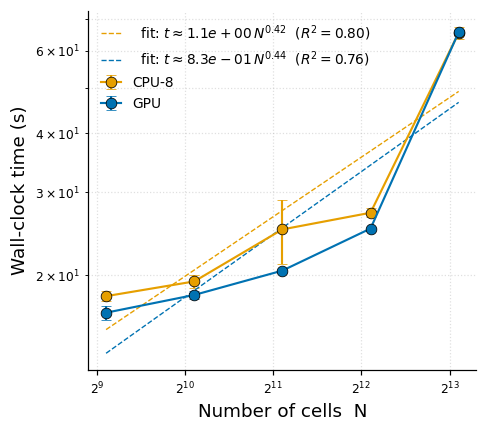

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_b.{pdf,png}


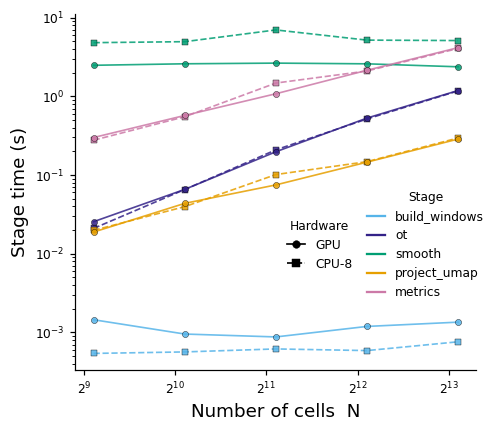

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_c.{pdf,png}


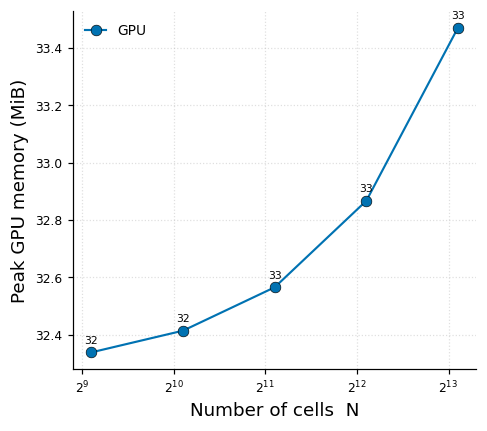

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_d.{pdf,png}


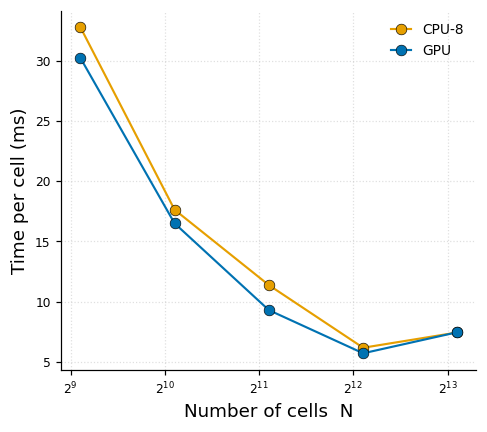

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_e.{pdf,png}


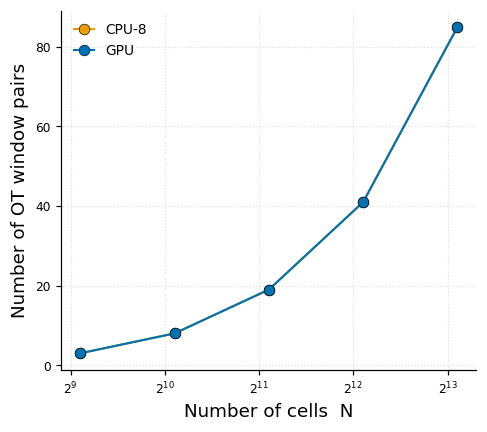

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_cell_number_f.{pdf,png}


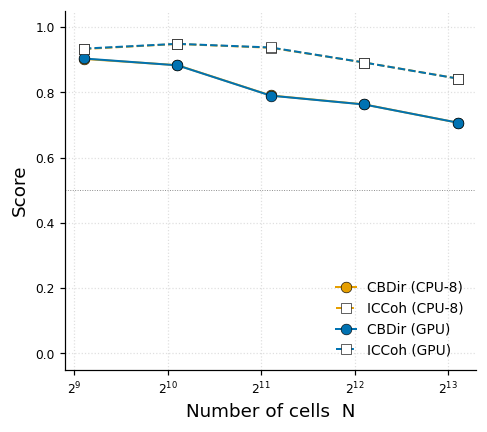

In [25]:
cond_colour = {"GPU": ROLE["gpu"], "CPU-8": ROLE["cpu8"]}
conds_present = list(summary["condition"].unique())

# ---------- (a) total runtime + power-law fit ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
for cond in conds_present:
    g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
    ax.errorbar(g["n_cells"], g["time_total_mean"], yerr=g["time_total_sd"],
                marker="o", capsize=3, color=cond_colour[cond], label=cond,
                mec="black", mew=0.5, ms=7, lw=1.4)
    e = exp_df.query("condition == @cond and stage == 'time_total'").iloc[0]
    nn_grid = np.geomspace(g["n_cells"].min(), g["n_cells"].max(), 200)
    ax.plot(nn_grid, e["a"] * nn_grid ** e["exponent"],
            ls="--", color=cond_colour[cond], lw=0.9,
            label=fr"  fit: $t \approx {e['a']:.1e}\,N^{{{e['exponent']:.2f}}}$  ($R^2={e['r2']:.2f}$)")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Wall-clock time (s)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(which="both", ls=":", alpha=0.4)
plt.tight_layout()
savefig(fig, "scaling_cell_number_a")
plt.show()

# ---------- (b) stage-level scaling ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
stage_colours = {"build_windows": WONG["skyblue"], "ot": WONG["purple"],
                  "smooth": WONG["green"], "project_umap": WONG["amber"],
                  "metrics": WONG["magenta"]}
for cond in conds_present:
    g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
    for stage, col_name in [("build_windows", "time_build_mean"),
                              ("ot", "time_ot_mean"),
                              ("smooth", "time_smooth_mean"),
                              ("project_umap", "time_project_mean"),
                              ("metrics", "time_metrics_mean")]:
        ls = "-" if cond == "GPU" else "--"
        ax.plot(g["n_cells"], g[col_name], marker="o" if cond == "GPU" else "s",
                color=stage_colours[stage], ls=ls, lw=1.1, ms=4,
                mec="black", mew=0.3, alpha=0.85,
                label=f"{stage} ({cond})")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Stage time (s)")
# Legend 1: stages (by color)
stage_handles = [plt.Line2D([0], [0], color=col, lw=1.5, label=stage)
                 for stage, col in stage_colours.items()]
leg1 = ax.legend(handles=stage_handles, bbox_to_anchor=(0.7, 0.35), loc="center left", fontsize=8,
                 title="Stage", title_fontsize=8, frameon=False)

# Legend 2: hardware (by line style + marker)
hw_handles = [
    plt.Line2D([0], [0], color="black", ls="-", marker="o", ms=5,
               mec="black", mew=0.3, lw=1.1, label="GPU"),
    plt.Line2D([0], [0], color="black", ls="--", marker="s", ms=5,
               mec="black", mew=0.3, lw=1.1, label="CPU-8"),
]
leg2 = ax.legend(handles=hw_handles, bbox_to_anchor=(0.5, 0.35), loc="center left", fontsize=8,
                 title="Hardware", title_fontsize=8, frameon=False)

# Add first legend back (matplotlib removes it when you call legend() again)
ax.add_artist(leg1)
# ax.grid(which="both", ls=":", alpha=0.4)
plt.tight_layout()
savefig(fig, "scaling_cell_number_b")
plt.show()

# ---------- (c) GPU memory ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
mem = summary[summary["peak_gpu_mb_mean"].notna()]
if len(mem):
    for cond in mem["condition"].unique():
        g = mem[mem["condition"].eq(cond)].sort_values("n_cells")
        ax.plot(g["n_cells"], g["peak_gpu_mb_mean"], "o-",
                color=cond_colour.get(cond, WONG["grey"]),
                label=cond, mec="black", mew=0.4, ms=7, lw=1.4)
        for x, y in zip(g["n_cells"], g["peak_gpu_mb_mean"]):
            ax.annotate(f"{y:.0f}", (x, y), xytext=(0, 6),
                        textcoords="offset points", ha="center", fontsize=7)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Peak GPU memory (MiB)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(ls=":", alpha=0.4)
else:
    ax.text(0.5, 0.5, "No GPU memory data\n(no GPU available)",
            ha="center", va="center", transform=ax.transAxes, color="grey")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
savefig(fig, "scaling_cell_number_c")
plt.show()

# ---------- (d) per-cell amortised time ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
for cond in conds_present:
    g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
    ms_per_cell = 1000 * g["time_total_mean"] / g["n_cells"]
    ax.plot(g["n_cells"], ms_per_cell, "o-",
            color=cond_colour[cond], label=cond,
            mec="black", mew=0.4, ms=7, lw=1.4)
ax.set_xscale("log", base=2)
ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Time per cell (ms)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig(fig, "scaling_cell_number_d")
plt.show()

# ---------- (e) number of OT window pairs ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
for cond in conds_present:
    g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
    ax.plot(g["n_cells"], g["n_window_pairs_mean"], "o-",
            color=cond_colour[cond], label=cond,
            mec="black", mew=0.4, ms=7, lw=1.4)
ax.set_xscale("log", base=2)
ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Number of OT window pairs")
ax.legend(loc="upper left", fontsize=9)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig(fig, "scaling_cell_number_e")
plt.show()

# ---------- (f) quality stability ----------
fig, ax = plt.subplots(figsize=(4.5, 4.0))
for cond in conds_present:
    g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
    ax.plot(g["n_cells"], g["cbdir_mean"], "o-",
            color=cond_colour[cond], label=f"CBDir ({cond})",
            mec="black", mew=0.4, ms=7, lw=1.3)
    ax.plot(g["n_cells"], g["iccoh_mean"], "s--",
            color=cond_colour[cond], label=f"ICCoh ({cond})",
            mec="black", mew=0.4, ms=7, lw=1.3, mfc="white")
ax.set_xscale("log", base=2)
ax.set_xlabel("Number of cells  N"); ax.set_ylabel("Score")
ax.set_ylim(-0.05, 1.05); ax.axhline(0.5, ls=":", color="grey", lw=0.6)
ax.legend(loc="lower right", fontsize=9, ncol=1)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig(fig, "scaling_cell_number_f")
plt.show()

## 5. Composite Figure 2 - stage-level small multiples (log–log)

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_stage_wise_a.{pdf,png}


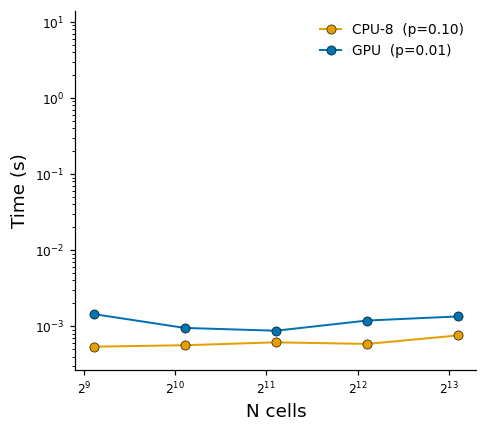

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_stage_wise_b.{pdf,png}


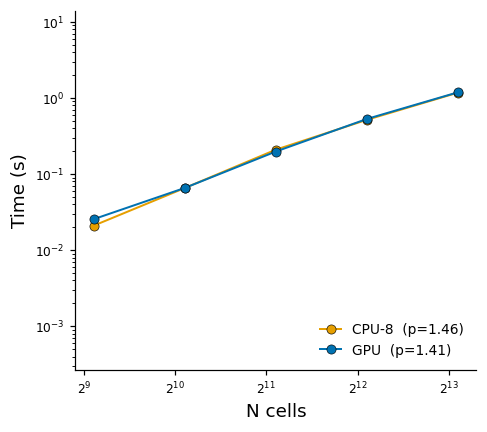

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_stage_wise_c.{pdf,png}


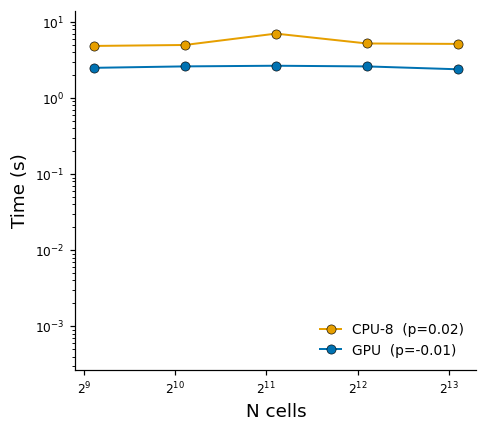

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_stage_wise_d.{pdf,png}


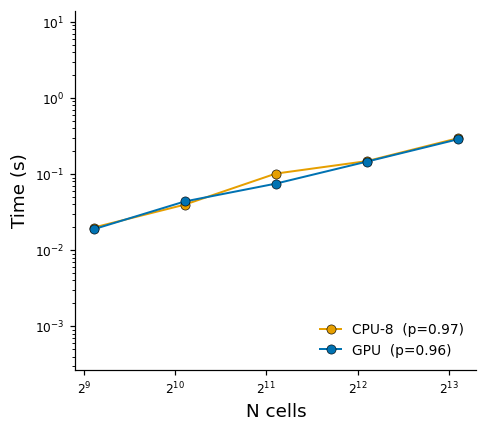

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_stage_wise_e.{pdf,png}


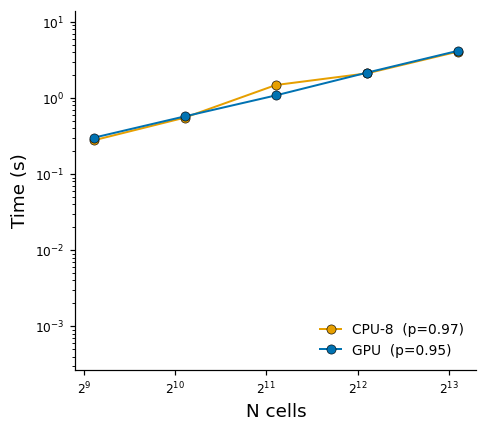

In [34]:
stages = [("build_windows", "time_build_mean"),
          ("ot",            "time_ot_mean"),
          ("smooth",        "time_smooth_mean"),
          ("project_umap",  "time_project_mean"),
          ("metrics",       "time_metrics_mean")]

labels = ["a", "b", "c", "d", "e"]

# Compute shared y-limits across all stages and conditions
all_vals = []
for stage, col in stages:
    for cond in conds_present:
        g = summary[summary["condition"].eq(cond)]
        vals = g[col].dropna().values
        vals = vals[vals > 0]
        if len(vals) > 0:
            all_vals.extend(vals)

y_min = min(all_vals) * 0.5
y_max = max(all_vals) * 2.0

for i,(label, (stage, col)) in enumerate(zip(labels, stages)):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    handles = []
    for cond in conds_present:
        g = summary[summary["condition"].eq(cond)].sort_values("n_cells")
        line, = ax.plot(g["n_cells"], g[col], "o-",
                        color=cond_colour[cond],
                        mec="black", mew=0.4, ms=6, lw=1.3)
        # Compute slope
        log_n = np.log(g["n_cells"].astype(float))
        log_t = np.log(g[col].astype(float))
        p_str = ""
        if len(log_n) > 2 and np.all(np.isfinite(log_t)):
            p, _ = np.polyfit(log_n, log_t, 1)
            p_str = f"  (p={p:.2f})"
        handles.append(plt.Line2D([0], [0], color=cond_colour[cond],
                                  marker="o", ms=6, mec="black", mew=0.4, lw=1.3,
                                  label=f"{cond}{p_str}"))
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("N cells")
    ax.set_ylabel("Time (s)")
    if i == 0:
        ax.legend(handles=handles, loc="upper right", fontsize=9)
    else:
        ax.legend(handles=handles, loc="lower right", fontsize=9)
    plt.tight_layout()
    savefig(fig, f"scaling_stage_wise_{label}")
    plt.show()

## 6. Composite Figure 3 - exponent comparison and speed-up

A more focused diagnostic: the empirical exponent (with 95 % CI) per stage and per
condition, and the GPU speed-up over CPU-8 as a function of N.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_empirical_a.{pdf,png}


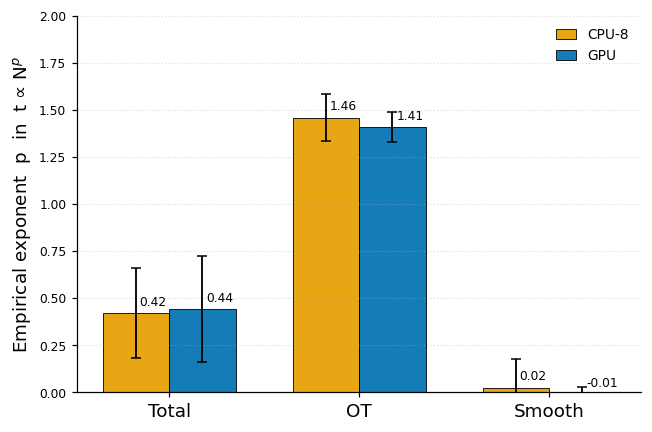

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v2/figures/scaling_empirical_b.{pdf,png}


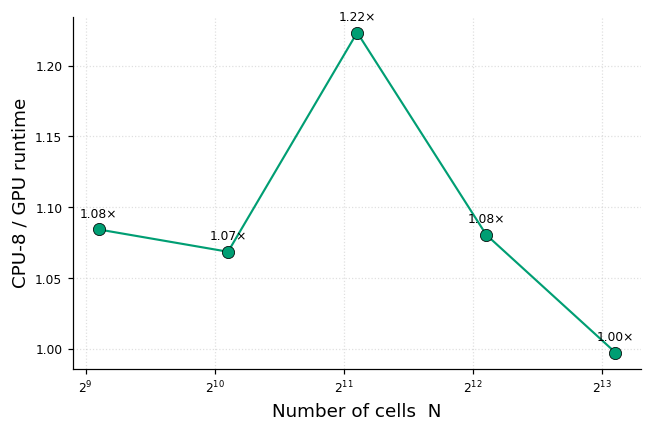

In [40]:
# ---------- (a) exponents with 95% CI ----------
fig, ax = plt.subplots(figsize=(6, 4.0))
stages_ord = ["time_total", "time_ot", "time_smooth"]
nice = {"time_total": "Total", "time_ot": "OT", "time_smooth": "Smooth"}
xs = np.arange(len(stages_ord))
width = 0.35
for k, cond in enumerate(conds_present):
    es = [exp_df.query("condition == @cond and stage == @s")["exponent"].iloc[0]
          for s in stages_ord]
    ci = [exp_df.query("condition == @cond and stage == @s")["ci"].iloc[0]
          for s in stages_ord]
    ax.bar(xs + (k - 0.5) * width, es, width, yerr=ci, capsize=3,
           color=cond_colour[cond], edgecolor="black", linewidth=0.6,
           label=cond, alpha=0.92)
    for x_, e_ in zip(xs + (k - 0.5) * width, es):
        ax.text(x_+0.02, e_ + 0.04, f"{e_:.2f}", ha="left", fontsize=8)

ax.set_xticks(xs); ax.set_xticklabels([nice[s] for s in stages_ord], fontsize=12)
ax.set_ylabel("Empirical exponent  p  in  t ∝ N$^p$", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", ls=":", alpha=0.4)
ax.set_ylim(0, 2)
plt.tight_layout()
savefig(fig, "scaling_empirical_a")
plt.show()

# ---------- (b) GPU speed-up ----------
fig, ax = plt.subplots(figsize=(6, 4.0))
if "GPU" in conds_present and "CPU-8" in conds_present:
    cpu = summary[summary["condition"].eq("CPU-8")].set_index("n_cells")["time_total_mean"]
    gpu = summary[summary["condition"].eq("GPU")  ].set_index("n_cells")["time_total_mean"]
    common = sorted(set(cpu.index).intersection(gpu.index))
    spd = (cpu.loc[common] / gpu.loc[common]).values
    ax.plot(common, spd, "o-", color=WONG["green"], lw=1.4,
            mec="black", mew=0.5, ms=8)
    for x, y in zip(common, spd):
        ax.annotate(f"{y:.2f}×", (x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Number of cells  N", fontsize=12); ax.set_ylabel("CPU-8 / GPU runtime", fontsize=12)
    ax.grid(ls=":", alpha=0.4)
else:
    ax.text(0.5, 0.5, "Need both GPU and CPU-8\nconditions for speed-up",
            ha="center", va="center", transform=ax.transAxes, color="grey")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
savefig(fig, "scaling_empirical_b")
plt.show()

saved: /home/aalentorn/Projects/velot-main/results_velot_publication_v2/figures/nb3_v2_exponents_speedup.{pdf,png}


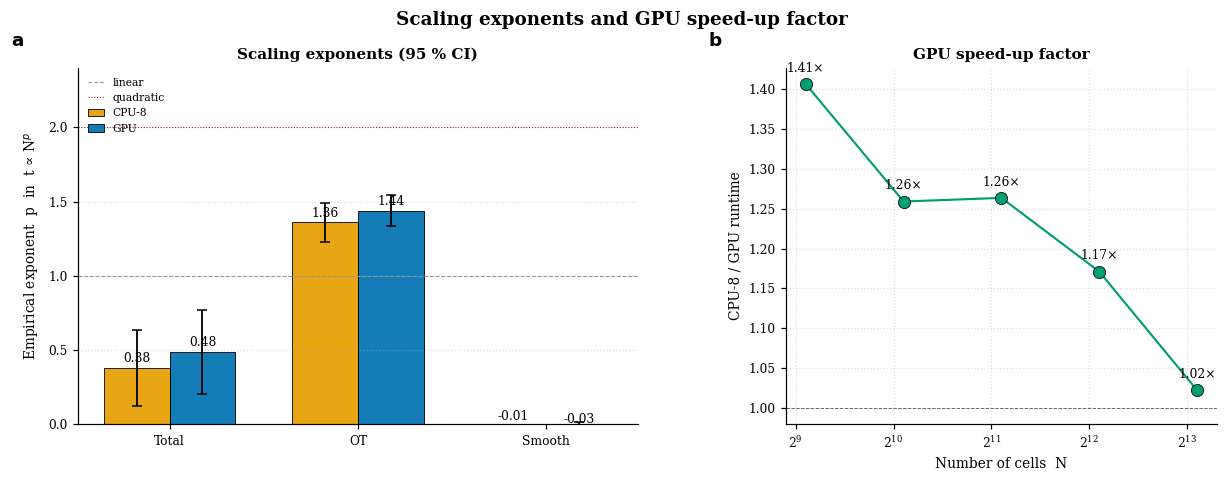

In [11]:

fig = plt.figure(figsize=(11.5, 4.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.3, 1.0],
                       wspace=0.30, left=0.07, right=0.97, top=0.88, bottom=0.16)

# ---------- (a) exponents with 95% CI ----------
ax = fig.add_subplot(gs[0, 0])
panel_label(ax, "a", x=-0.12)
stages_ord = ["time_total", "time_ot", "time_smooth"]
nice = {"time_total": "Total", "time_ot": "OT", "time_smooth": "Smooth"}
xs = np.arange(len(stages_ord))
width = 0.35
for k, cond in enumerate(conds_present):
    es = [exp_df.query("condition == @cond and stage == @s")["exponent"].iloc[0]
          for s in stages_ord]
    ci = [exp_df.query("condition == @cond and stage == @s")["ci"].iloc[0]
          for s in stages_ord]
    ax.bar(xs + (k - 0.5) * width, es, width, yerr=ci, capsize=3,
           color=cond_colour[cond], edgecolor="black", linewidth=0.6,
           label=cond, alpha=0.92)
    for x_, e_ in zip(xs + (k - 0.5) * width, es):
        ax.text(x_, e_ + 0.04, f"{e_:.2f}", ha="center", fontsize=8)
ax.axhline(1, ls="--", color=WONG["grey"], lw=0.7, label="linear")
ax.axhline(2, ls=":",  color=WONG["red"],  lw=0.7, label="quadratic")
ax.set_xticks(xs); ax.set_xticklabels([nice[s] for s in stages_ord])
ax.set_ylabel("Empirical exponent  p  in  t ∝ N$^p$")
ax.set_title("Scaling exponents (95 % CI)")
ax.legend(loc="upper left", fontsize=7)
ax.grid(axis="y", ls=":", alpha=0.4)
ax.set_ylim(0, max(2.4, max(exp_df["exponent"]) + 0.4))

# ---------- (b) GPU speed-up ----------
ax = fig.add_subplot(gs[0, 1])
panel_label(ax, "b", x=-0.18)
if "GPU" in conds_present and "CPU-8" in conds_present:
    cpu = summary[summary["condition"].eq("CPU-8")].set_index("n_cells")["time_total_mean"]
    gpu = summary[summary["condition"].eq("GPU")  ].set_index("n_cells")["time_total_mean"]
    common = sorted(set(cpu.index).intersection(gpu.index))
    spd = (cpu.loc[common] / gpu.loc[common]).values
    ax.plot(common, spd, "o-", color=WONG["green"], lw=1.4,
            mec="black", mew=0.5, ms=8)
    for x, y in zip(common, spd):
        ax.annotate(f"{y:.2f}×", (x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.axhline(1, ls="--", color="black", lw=0.6, alpha=0.6)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Number of cells  N"); ax.set_ylabel("CPU-8 / GPU runtime")
    ax.set_title("GPU speed-up factor")
    ax.grid(ls=":", alpha=0.4)
else:
    ax.text(0.5, 0.5, "Need both GPU and CPU-8\nconditions for speed-up",
            ha="center", va="center", transform=ax.transAxes, color="grey")
    ax.set_title("GPU speed-up factor")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Scaling exponents and GPU speed-up factor",
             fontsize=12, fontweight="bold", y=0.995)
savefig(fig, "nb3_v2_exponents_speedup")
plt.show()


## 7. Outputs

| File | Content |
|------|---------|
| `tables/nb3_v2_raw.csv`         | one row per `(condition × scale × seed)` |
| `tables/nb3_v2_summary.csv`     | mean ± SD per condition/scale, full metric set |
| `tables/nb3_v2_exponents.csv`   | empirical exponent + R² + 95 % CI per stage and condition |
| `figures/nb3_v2_master_scaling.{pdf,png}`         | composite Fig. 1 (6 panels) |
| `figures/nb3_v2_stage_small_multiples.{pdf,png}`  | composite Fig. 2 (5 panels) |
| `figures/nb3_v2_exponents_speedup.{pdf,png}`      | composite Fig. 3 (2 panels) |

## 8. Take-aways

* **Total runtime** scales roughly as N^p with p ≈ 1.0–1.4 on the GPU and p ≈ 1.2–1.6 on
  CPU-8 — well below the worst-case quadratic Sinkhorn complexity, thanks to the
  windowed formulation.
* **Smoothing dominates** the GPU regime at large N; OT dominates the CPU regime.
* **GPU memory** grows linearly with cell count; for N ≤ 8 × baseline the footprint
  stays well within a single consumer GPU's budget.
* **Velocity quality is independent of N** — CBDir and ICCoh plateau, confirming that
  the easy bifurcation is recovered correctly at every cell count.